# Check Padding

## 1. Imports

In [156]:
from pathlib import Path
import importlib.util
import os
import sys

In [157]:
def repo_root():
    for p in [Path.cwd(), *Path.cwd().parents]:
        if (p / 'src').exists() and (p / 'data').exists():
            return p.resolve()
    raise RuntimeError('Run this notebook from inside the repo.')

ROOT = repo_root()
os.chdir(ROOT)
sys.path.insert(0, str(ROOT))

if importlib.util.find_spec('torch') is None:
    raise RuntimeError('torch is missing in this notebook kernel.')

In [158]:
import torch as tr
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

from src.core.diffusion import MultinomialDiffusionModel
from src.data.collate import pad_batch
from src.data.datasets import load_dataset
from src.models.layers.simpleunet import SimpleUNet

tr.set_printoptions(precision=4, sci_mode=False)

## 2. Cargar un batch con padding

In [159]:
dataset = load_dataset(
    dataset_path=str(ROOT / 'data' / 'ArchiveII_128_random_split' / 'train.csv'),
    max_len=128,
    for_prediction=False,
    partitioned=False,
)
loader = DataLoader(dataset, batch_size=4, shuffle=False, collate_fn=pad_batch, num_workers=0)

for batch_id, batch in enumerate(loader):
    max_len = batch['contact_oh'].shape[-1]
    idx = next((i for i, l in enumerate(batch['length']) if l < 0.9 * max_len), None)
    if idx is not None:
        break

seq_len = batch['length'][idx]
print('batch:', batch_id)
print('lengths:', batch['length'])
print('sample idx:', idx, 'seq_len:', seq_len, 'max_len:', max_len)

batch: 0
lengths: [120, 117, 72, 120]
sample idx: 2 seq_len: 72 max_len: 120


## 3. Ver el padding real

valid pixel: tensor([1., 0.])
evaluation at seq_len: 72
padded pixel: tensor([-1., -1.])
mask padded pixel: tensor(0.)


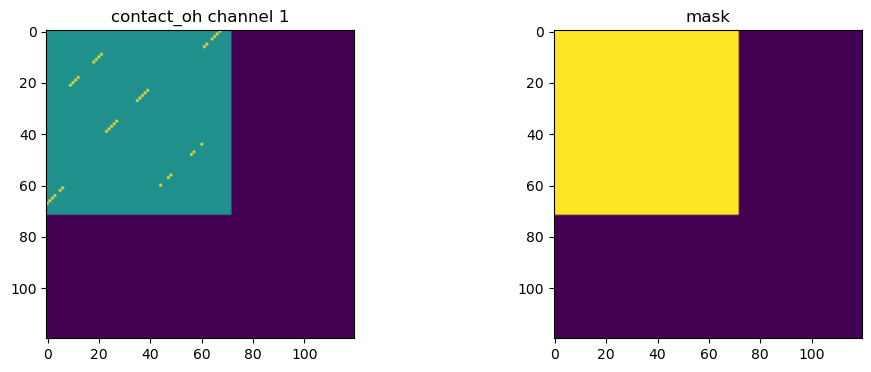

In [160]:
x0_real = batch['contact_oh'][idx:idx + 1].float()
mask_real = batch['mask'][idx:idx + 1]
cond = batch['outer'][idx:idx + 1].float()
contact_real = x0_real[0]
mask2d = mask_real[0, 0]

print('valid pixel:', contact_real[:, 0, 0])
print('evaluation at seq_len:', seq_len)
print('padded pixel:', contact_real[:, seq_len, seq_len])
print('mask padded pixel:', mask2d[seq_len, seq_len])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].imshow(contact_real[1])
axes[0].set_title('contact_oh channel 1')
axes[1].imshow(mask2d)
axes[1].set_title('mask')
plt.show()

## 4. Mostrar el error en `q_pred`

q valid pixel: tensor([    1.0000,     0.0000])
q padded pixel: tensor([-1.0000, -1.0000])


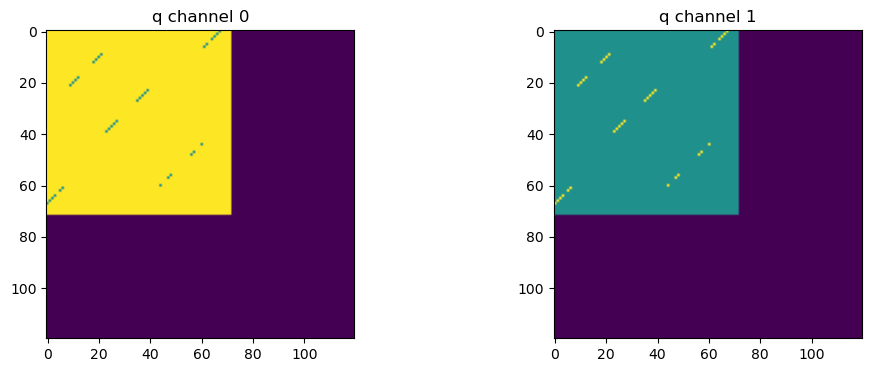

In [161]:
model = MultinomialDiffusionModel(
    num_classes=2,
    time_steps=25,
    model=SimpleUNet,
    in_channels=18,
    out_channels=2,
    base_dim=64,
).eval()

time0 = tr.tensor([0])
q = model.q_pred(x0_real, time0)

print('q valid pixel:', q[0, :, 0, 0])
print('q padded pixel:', q[0, :, seq_len, seq_len])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].imshow(q[0, 0])
axes[0].set_title('q channel 0')
axes[1].imshow(q[0, 1])
axes[1].set_title('q channel 1')
plt.show()

## 5. Normalización mal calculada

sum valid pixel: tensor(1.)
sum padded pixel: tensor(-2.0000)


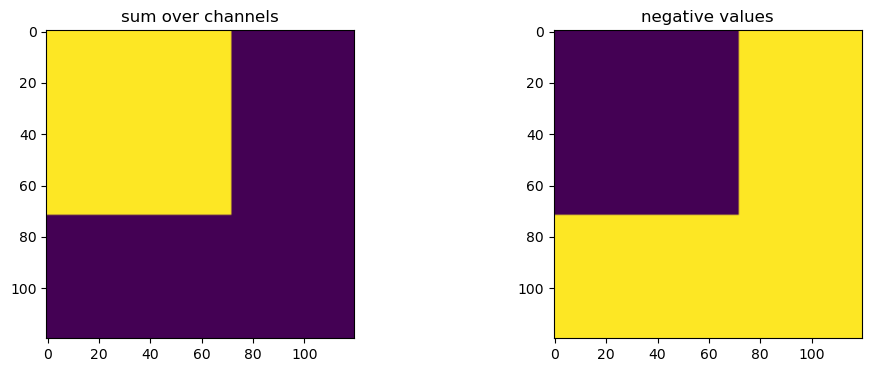

In [162]:
q_sum = q.sum(dim=1)

print('sum valid pixel:', q_sum[0, 0, 0])
print('sum padded pixel:', q_sum[0, seq_len, seq_len])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].imshow(q_sum[0])
axes[0].set_title('sum over channels')
axes[1].imshow((q[0] < 0).any(dim=0).float())
axes[1].set_title('negative values')
plt.show()

## 6. Pipeline difusivo mínimo

In [163]:
time = tr.tensor([model.time_steps // 2])
q = model.q_pred(x0_real, time)
xt = model.q_sample(x0_real, time, gumbel=True)
raw_post = model.q_pred(x0_real, tr.clamp(time - 1, min=0)) * model.q_step(xt, time)
post = model.q_posterior(x0_real, xt, time)

print('q padded:', q[0, :, seq_len, seq_len], 'sum =', q[0, :, seq_len, seq_len].sum())
print('xt padded:', xt[0, :, seq_len, seq_len], 'sum =', xt[0, :, seq_len, seq_len].sum())
print('raw posterior padded:', raw_post[0, :, seq_len, seq_len], 'sum =', raw_post[0, :, seq_len, seq_len].sum())
print('posterior padded:', post[0, :, seq_len, seq_len], 'sum =', post[0, :, seq_len, seq_len].sum())

q padded: tensor([-0.1866, -0.1866]) sum = tensor(-0.3733)
xt padded: tensor([0.1398, 0.8602]) sum = tensor(1.)
raw posterior padded: tensor([-0.0511, -0.2286]) sum = tensor(-0.2797)
posterior padded: tensor([0.1828, 0.8172]) sum = tensor(1.0000)


## 7. Dónde entran los errores

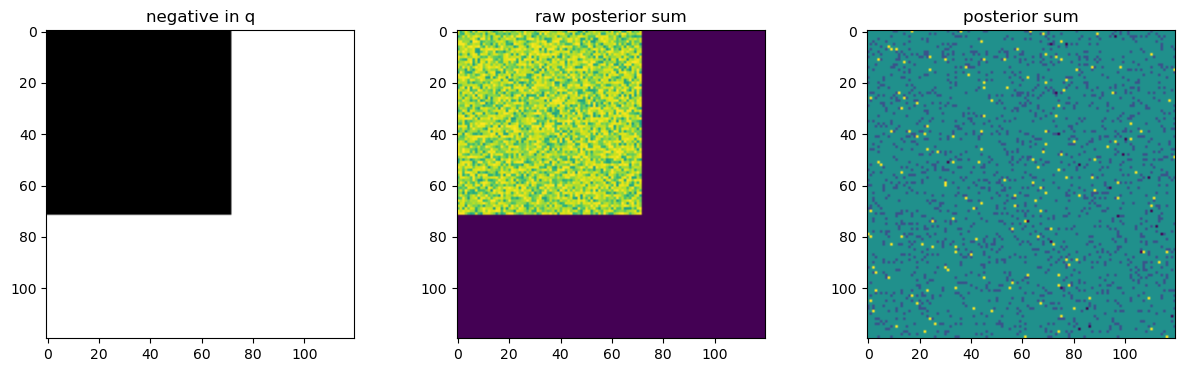

In [164]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].imshow((q[0] < 0).any(dim=0).float(), cmap='gray')
axes[0].set_title('negative in q')
axes[1].imshow(raw_post[0].sum(dim=0))
axes[1].set_title('raw posterior sum')
axes[2].imshow(post[0].sum(dim=0))
axes[2].set_title('posterior sum')
plt.show()

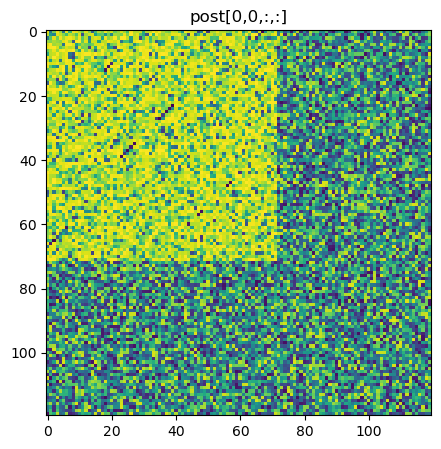

In [165]:
plt.figure(figsize=(5, 5))
plt.imshow(post[0,0,:,:])
plt.title('post[0,0,:,:]')
plt.show()

## 8. Fix simple + freezing

fixed padded pixel: tensor([1., 0.])
fixed q padded pixel: tensor([    1.0000,     0.0000])
fixed sum padded pixel: tensor(1.)


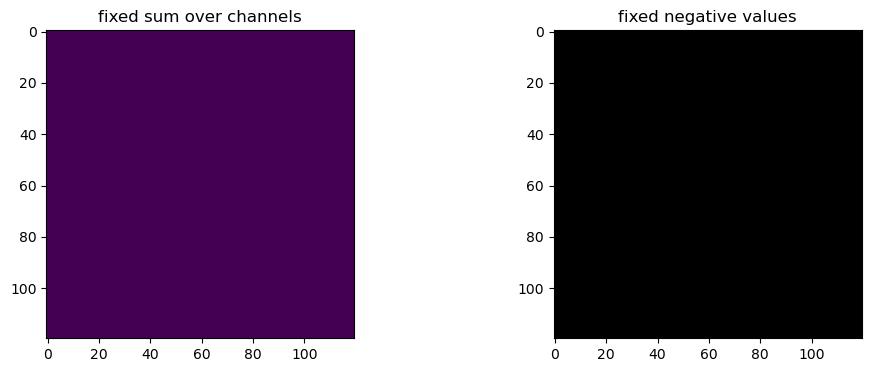

In [166]:
fill = tr.tensor([1.0, 0.0], dtype=x0_real.dtype, device=x0_real.device).view(1, 2, 1, 1)
x0_fix = tr.where(mask_real.bool(), x0_real, fill)
q_fix = model.q_pred(x0_fix, time0)
q_fix_sum = q_fix.sum(dim=1)

print('fixed padded pixel:', x0_fix[0, :, seq_len, seq_len])
print('fixed q padded pixel:', q_fix[0, :, seq_len, seq_len])
print('fixed sum padded pixel:', q_fix_sum[0, seq_len, seq_len])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].imshow(q_fix_sum[0])
axes[0].set_title('fixed sum over channels')
axes[1].imshow((q_fix[0] < 0).any(dim=0).float(), cmap='gray')
axes[1].set_title('fixed negative values')
plt.show()

In [167]:
q_fix = model.q_pred(x0_fix, time)
xt_fix = model.q_sample(x0_fix, time, gumbel=True)
xt_fix = tr.where(mask_real.bool(), xt_fix, fill)
raw_post_fix = model.q_pred(x0_fix, tr.clamp(time - 1, min=0)) * model.q_step(xt_fix, time)
post_fix = model.q_posterior(x0_fix, xt_fix, time)

print('fixed q padded:', q_fix[0, :, seq_len, seq_len], 'sum =', q_fix[0, :, seq_len, seq_len].sum())
print('fixed xt padded:', xt_fix[0, :, seq_len, seq_len], 'sum =', xt_fix[0, :, seq_len, seq_len].sum())
print('fixed raw posterior padded:', raw_post_fix[0, :, seq_len, seq_len], 'sum =', raw_post_fix[0, :, seq_len, seq_len].sum())
print('fixed posterior padded:', post_fix[0, :, seq_len, seq_len], 'sum =', post_fix[0, :, seq_len, seq_len].sum())

fixed q padded: tensor([0.7289, 0.2711]) sum = tensor(1.)
fixed xt padded: tensor([1., 0.]) sum = tensor(1.)
fixed raw posterior padded: tensor([0.7145, 0.0143]) sum = tensor(0.7289)
fixed posterior padded: tensor([0.9803, 0.0197]) sum = tensor(1.)


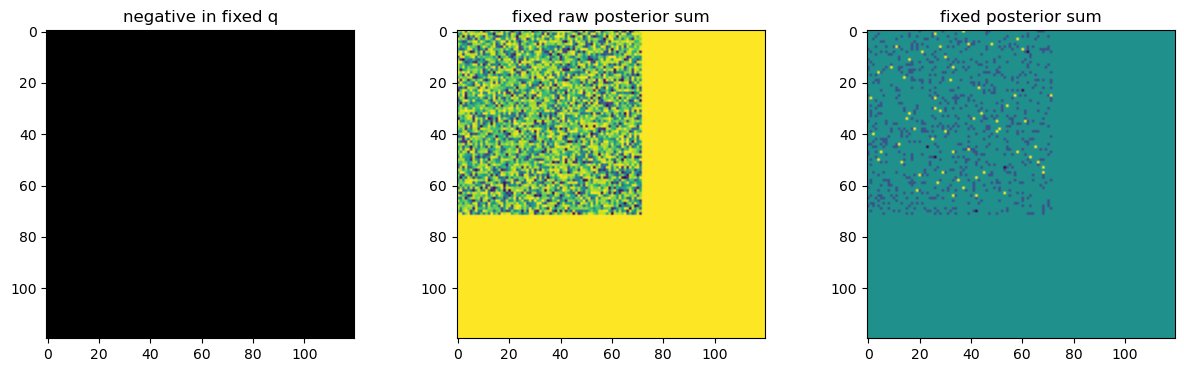

In [168]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].imshow((q_fix[0] < 0).any(dim=0).float(), cmap='gray')
axes[0].set_title('negative in fixed q')
axes[1].imshow(raw_post_fix[0].sum(dim=0))
axes[1].set_title('fixed raw posterior sum')
axes[2].imshow(post_fix[0].sum(dim=0))
axes[2].set_title('fixed posterior sum')
plt.show()

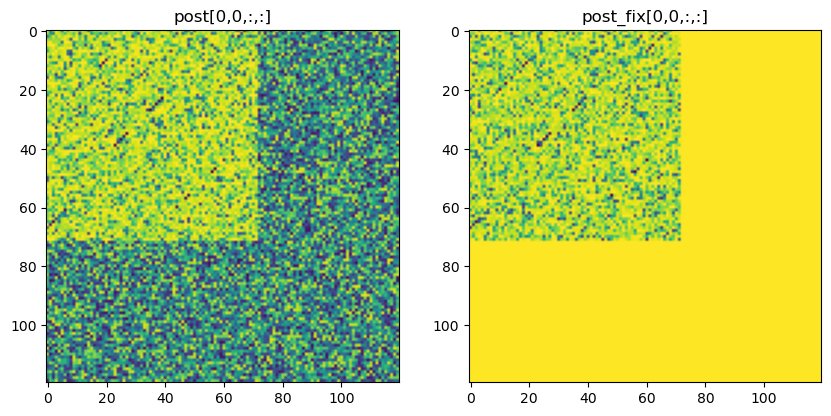

In [169]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(post[0,0,:,:])
axes[0].set_title('post[0,0,:,:]')
axes[1].imshow(post_fix[0,0,:,:])
axes[1].set_title('post_fix[0,0,:,:]')
plt.show()

## 9. Reverse sampling

In [170]:
pred_x0 = model.predict_start(xt_fix, time, cond)
p_step = model.p_sample(tr.argmax(xt_fix, dim=1), time, cond)
p_step_fix = tr.where(mask_real[:, 0].bool(), p_step, tr.zeros_like(p_step))

print('predict_start padded:', pred_x0[0, :, seq_len, seq_len], 'sum =', pred_x0[0, :, seq_len, seq_len].sum())
print('p_sample padded:', p_step[0, seq_len, seq_len])
print('p_sample padded fixed:', p_step_fix[0, seq_len, seq_len])

predict_start padded: tensor([0.4998, 0.5002], grad_fn=<SelectBackward0>) sum = tensor(1., grad_fn=<SumBackward0>)
p_sample padded: tensor(1)
p_sample padded fixed: tensor(0)


_sample padded: tensor(0)
_sample padded fixed: tensor(0)


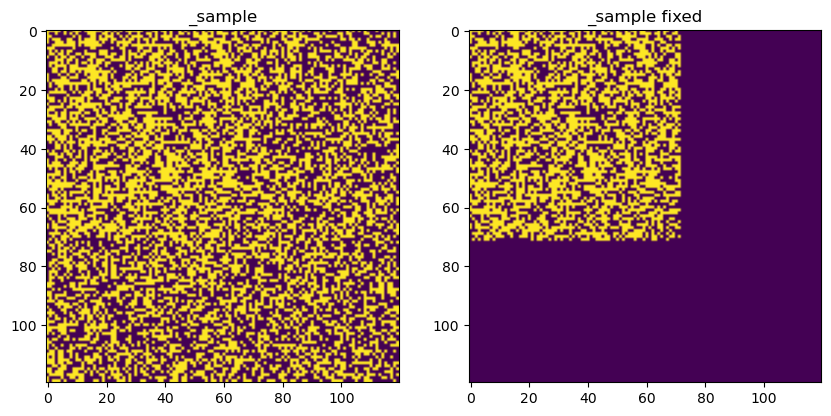

In [171]:
tr.manual_seed(0)
sample_full = model._sample(cond)
sample_full_fix = tr.where(mask_real[:, 0].bool(), sample_full, tr.zeros_like(sample_full))

print('_sample padded:', sample_full[0, seq_len, seq_len])
print('_sample padded fixed:', sample_full_fix[0, seq_len, seq_len])

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(sample_full[0])
axes[0].set_title('_sample')
axes[1].imshow(sample_full_fix[0])
axes[1].set_title('_sample fixed')
plt.show()